This notebook performs analyses on the frozen model established in 02_baselines.ipynb. 

The Goal is not to improve performance, but to understand structural limitations such as sparsity, fragmented categorical signal...

These findings will motivate subsequent feature engineering decisions

In [ ]:
# reload baseline pipeline exactly as defined in 02_baselines.ipynb

import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.data import load_train_data

data = load_train_data()

# define target, X, y
TARGET = 'SalePrice'

y = np.log1p(data[TARGET])
X = data.drop(columns=[TARGET]) # everything less the target

nominal_cols = ['MSZoning','MSSubClass', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType','Foundation', 'Heating','CentralAir', 'Electrical','Functional',
       'GarageType', 'GarageFinish','PavedDrive','MiscFeature',
       'SaleType', 'SaleCondition','Fence',
]

ordinal_cols = ['OverallQual','OverallCond','ExterQual', 'ExterCond',
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                'HeatingQC','KitchenQual','FireplaceQu','GarageQual',
                'GarageCond','PoolQC'

]

categorical_cols = nominal_cols + ordinal_cols

num_structured_missing = ['MasVnrArea','GarageYrBlt']
num_unstruc_missing = ['LotFrontage']

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

num_struc_missing_pipeline = Pipeline([
  ('imputer',
   SimpleImputer(strategy='constant',
   fill_value = 0)),
  ('scaler',StandardScaler())
])

num_unstruc_missing_pipeline = Pipeline([
  ('imputer',
   SimpleImputer(strategy='median')),
   ('scaler',StandardScaler())
])

other_numerical_cols = [
  col for col in data.columns
  if col not in nominal_cols + ordinal_cols + ["SalePrice"] + num_structured_missing + num_unstruc_missing
]

other_num_pipeline = Pipeline([
  ('imputer',
   SimpleImputer(strategy='median')),
   ('scaler',StandardScaler())
])

categorcal_pipeline = Pipeline([
  ('imputer',
   SimpleImputer(strategy='most_frequent')),
   ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
  ('num_zero', num_struc_missing_pipeline,
   num_structured_missing),
   ('num_median', num_unstruc_missing_pipeline,
    num_unstruc_missing),
    ('other_num', other_num_pipeline,
     other_numerical_cols),
    ('cat', categorcal_pipeline,
    categorical_cols )
])

model = Ridge(alpha=1.0)
pipeline = Pipeline([
  ('preprocess',preprocessor),
  ('model',model)
])

In [3]:
rare_amenities_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

for col in rare_amenities_cols:
  freq = data[col].value_counts(dropna=False, normalize=True)
  print(f"\n{col} frequency:")
  print(freq.head(10))


PoolQC frequency:
PoolQC
NaN    0.995205
Gd     0.002055
Ex     0.001370
Fa     0.001370
Name: proportion, dtype: float64

MiscFeature frequency:
MiscFeature
NaN     0.963014
Shed    0.033562
Gar2    0.001370
Othr    0.001370
TenC    0.000685
Name: proportion, dtype: float64

Alley frequency:
Alley
NaN     0.937671
Grvl    0.034247
Pave    0.028082
Name: proportion, dtype: float64

Fence frequency:
Fence
NaN      0.807534
MnPrv    0.107534
GdPrv    0.040411
GdWo     0.036986
MnWw     0.007534
Name: proportion, dtype: float64


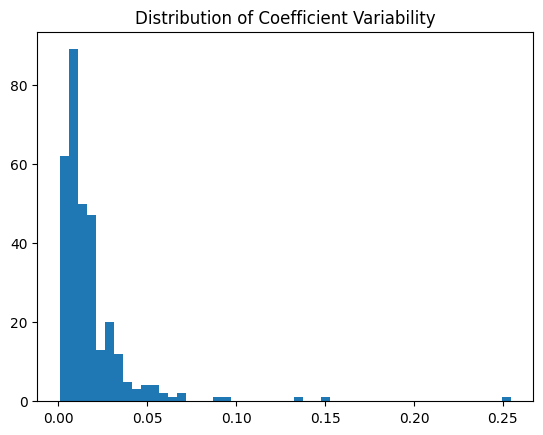

In [14]:
all_categories = [
    sorted(data[col].dropna().unique())
    for col in categorical_cols
]

preprocessor = ColumnTransformer([
    ('num_zero', num_struc_missing_pipeline, num_structured_missing),
    ('num_median', num_unstruc_missing_pipeline, num_unstruc_missing),
    ('other_num', other_num_pipeline, other_numerical_cols),
    ('cat', categorcal_pipeline, categorical_cols)
])

model = Ridge(alpha=1.0)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

from sklearn.model_selection import KFold
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=42)

coef_list = []

for tr, va in kf.split(X):

    pipe = clone(pipeline)
    pipe.fit(X.iloc[tr], y.iloc[tr])

    coef_list.append(pipe.named_steps['model'].coef_)

    feature_names = pipe.named_steps['preprocess'].get_feature_names_out()

coef_matrix = np.vstack(coef_list)

coef_std = coef_matrix.std(axis=0)

instability = pd.Series(coef_std, index = feature_names)
instability_sorted = instability.sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.hist(coef_std, bins=50)
plt.title("Distribution of Coefficient Variability")
plt.show()

In [15]:
instability_sorted.head(15)

cat__RoofMatl_ClyTile       0.254430
cat__Condition2_PosN        0.148536
cat__PoolQC_Gd              0.137203
cat__PoolQC_Ex              0.095309
cat__OverallQual_1          0.088643
cat__Exterior1st_BrkComm    0.067579
cat__RoofMatl_WdShngl       0.067480
cat__RoofMatl_WdShake       0.066636
cat__RoofMatl_CompShg       0.060942
cat__RoofMatl_Membran       0.057252
cat__Condition2_PosA        0.054385
cat__OverallCond_2          0.052529
cat__RoofMatl_Tar&Grv       0.052211
cat__Condition2_Norm        0.052207
cat__Heating_Grav           0.051616
dtype: float64

In [11]:
print('GrLivArea' in X)

True


When trying to analyse coefficient stability, a bug occurred, and it was found to be caused by encoded feature dimensionality itself fluctuated acorss CV folds because rare categories disappeared from training 

In [6]:
oof = np.zeros(len(X))

for tr, va in kf.split(X):

    pipe = clone(pipeline)
    pipe.fit(X.iloc[tr], y.iloc[tr])

    oof[va] = pipe.predict(X.iloc[va])

residuals = y - oof

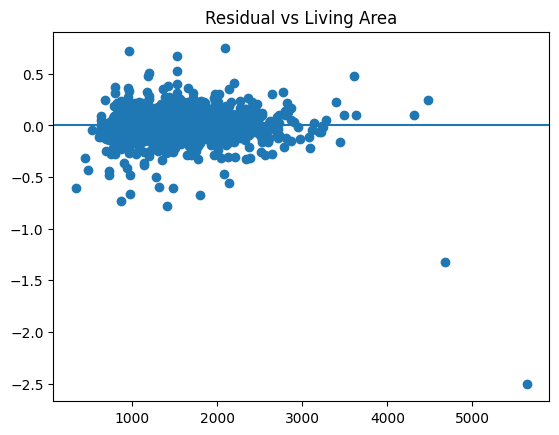

In [12]:
import matplotlib.pyplot as plt
plt.scatter(data['GrLivArea'], residuals)
plt.axhline(0)
plt.title("Residual vs Living Area")
plt.show()